<table width=100%>
<tr>
<td width=60%>
<h1><b>MET/MATT Computer Vision with Deep Learning</b></h1>
<h2><b>Lab7 - Motion and Tracking</b></h2>
<br>
<h4>2020-2021 - Josep Ramon Morros
<br>
<a href="https://imatge.upc.edu/web/"> GPI @ IDEAI</a> Research group
<a href="https://telecos.upc.edu/ca">ETSETB – UPC.TelecosBCN</a></h4>
</td>
<td style="text-align: right;" width=40%>
<img src="https://drive.google.com/uc?export=view&id=1tAyPa600X2kvCmWEIPbkdDGFgZPaMziC" width=300>
</td>
</tr>
</table>



## **1. Optical Flow computation**

In this part you will study how to compute optical flow. We will use the C. Liu's [2] implementation of the Brox robust optical flow method [1]. The method uses a multiresolution approach and a  non-linearized version of the brightness-constancy equation, among other details. C. Liu added additional improvements to the method [2].

First, we will install the pyflow github repository, which is a python wrapper to the C++ implementation from C. Liu [3]

In [1]:
"""
%cd /content
%pip install apng  # To create animated png's
# Clone pyflow repository
!git clone https://github.com/pathak22/pyflow.git
# Build the package
%cd pyflow/
!python setup.py build_ext -i
rm token.json
"""

"\n%cd /content\n%pip install apng  # To create animated png's\n# Clone pyflow repository\n!git clone https://github.com/pathak22/pyflow.git\n# Build the package\n%cd pyflow/\n!python setup.py build_ext -i\nrm token.json\n"

In [2]:
import cv2
import pyflow
import numpy as np
import time
from IPython.display import Image # To display images in Colab
from apng import APNG # To create animated png's

In [3]:
im1 = cv2.imread('examples/car1.jpg')
im2 = cv2.imread('examples/car2.jpg')
im1 = im1.astype(float) / 255.
im2 = im2.astype(float) / 255.

[ WARN:0@0.623] global loadsave.cpp:278 findDecoder imread_('examples/car1.jpg'): can't open/read file: check file path/integrity
[ WARN:0@0.623] global loadsave.cpp:278 findDecoder imread_('examples/car2.jpg'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'astype'

Let's visualize the test images:

/Users/esteve/dev/cvdl/motion_tracking/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


[Errno 2] No such file or directory: '/content/pyflow'
/Users/esteve/dev/cvdl/motion_tracking/pyflow/pyflow


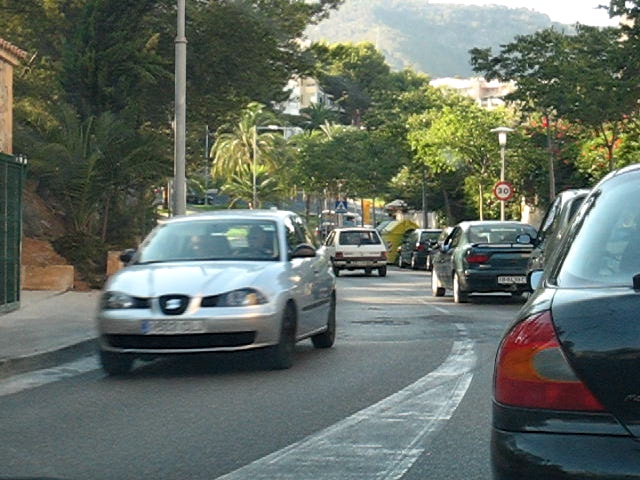

In [ ]:
%cd /content/pyflow
APNG.from_files(['examples/car1.jpg', 'examples/car2.jpg'], delay=800).save("result.png")
Image('result.png')

The number of resolution levels is determined using two parameters: ***ratio*** and ***minWidth***. *ratio* determines the reduction in size factor when downsampling the images at each resolution level. *minWidth* determines the width (in pixels) of the lowest level of the pyramid.

Now, we define the OF parameters:

In [ ]:
# Flow Options:
alpha = 0.012
ratio = 0.75
minWidth = 20
nOuterFPIterations = 7
nInnerFPIterations = 1
nSORIterations = 30
colType = 0  # 0 or default:RGB, 1:GRAY (but pass gray image with shape (h,w,1))

Let's perform the optical flow estimation with the selected parameters:

In [ ]:
s = time.time()
u, v, im2W = pyflow.coarse2fine_flow(
    im1, im2, alpha, ratio, minWidth, nOuterFPIterations, nInnerFPIterations,
    nSORIterations, colType)
e = time.time()
print('Time Taken: {:.2f} seconds for image of size ({},{},{})'.format(e - s, im1.shape[0], im1.shape[1], im1.shape[2]))
cv2.imwrite('examples/car2W.jpg', (im2W*255).astype(int))

Constructing pyramid...Time Taken: 4.13 seconds for image of size (480,640,3)
done!
Pyramid level 11
Pyramid level 10
Pyramid level 9
Pyramid level 8
Pyramid level 7
Pyramid level 6
Pyramid level 5
Pyramid level 4
Pyramid level 3
Pyramid level 2
Pyramid level 1
Pyramid level 0


[ WARN:0@6.228] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


True

In the output variable *im2W* we have the compensated image.

<font color='red'><b>P1: Write the code to compute the DFD to evaluate the quality of the optical flow. Use the RMSE measure (Root Mean Square Error) for the DFD.</b></font>

In [ ]:
import numpy as np
def dfd_rmse(ima1, ima2):
  diff = ima1 - ima2
  mse = np.mean(diff ** 2)
  return np.sqrt(mse)


Compute the DFD value using this set of parameters.

In [ ]:
dfd_val1 = dfd_rmse(im1, im2W)
print ('The DFD (RMSE) is {:.3f}'.format(dfd_val1))

The DFD (RMSE) is 0.029


Another way to judge the quality of a flow field is to check that:

*   The brightness constancy assumption is satisfied, namely when you flip back and forth frame 1 and motion compensated frame 2, you shouldn't see any movement.
*   The discontinuity of the flow field agrees with the object boundaries.

For this, we will create an animated png with both frame1 and warped frame 2:

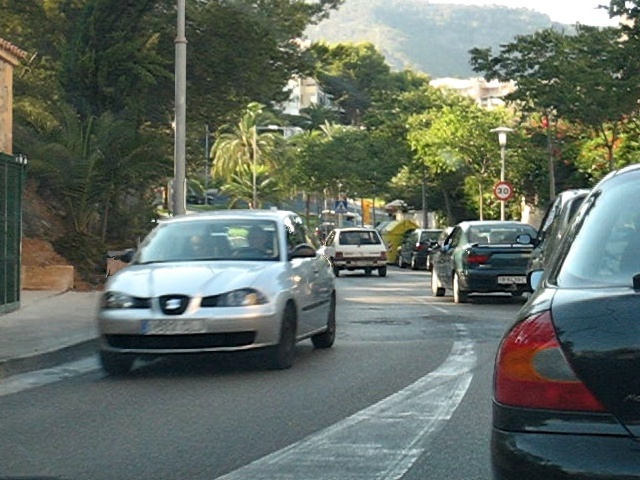

In [ ]:
APNG.from_files(["examples/car2W.jpg", "examples/car1.jpg"], delay=800).save("result.png")
Image('result.png')

<font color='red'><b>Q1: Explain which is the function of the parameter *alpha*</b></font> (Hint: look at the slides of the course: ICV_U4_motion_tracking_v3, slide 53.

<font color='blue'>Its the smoothness term. A high alpha makes the flow field smooth and less sensitive to fine detail. Lower alpha makes the flow field more close to the gradients but more noisy. Its a tradeoff.</font>

<font color='red'><b>Q2: Now, change parameter alpha (higher and lower value) and explain how the results differ depending on this parameter.</b></font> (NOTE: use the dfd_rmse() function for quantitative results and the animated png for qualitative results

In [ ]:
alpha = 0.1

s = time.time()
u, v, im2W = pyflow.coarse2fine_flow(
    im1, im2, alpha, ratio, minWidth, nOuterFPIterations, nInnerFPIterations,
    nSORIterations, colType)
e = time.time()
print('Time Taken: {:.2f}s for image of size ({}, {}, {})'.format(e - s, im1.shape[0], im1.shape[1], im1.shape[2]))
cv2.imwrite('examples/car2W.jpg', (im2W*255).astype(int))


Constructing pyramid...done!
Pyramid level 11
Pyramid level 10
Pyramid level 9
Pyramid level 8
Pyramid level 7
Pyramid level 6
Pyramid level 5
Pyramid level 4
Pyramid level 3
Pyramid level 2
Pyramid level 1
Pyramid level 0
Time Taken: 4.13s for image of size (480, 640, 3)


True

The DFD (RMSE) is 0.03943972544995754


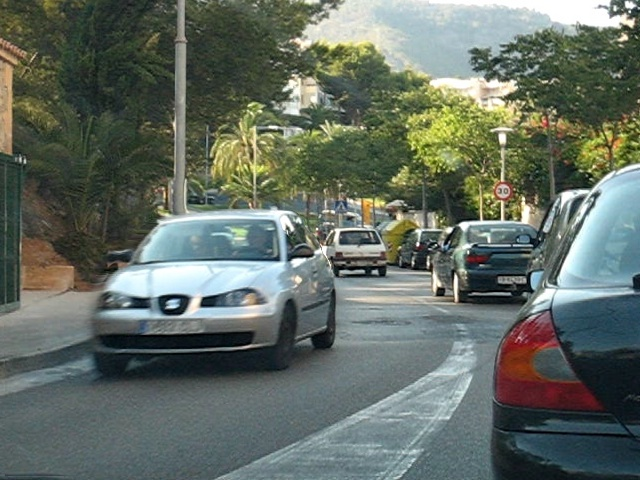

In [ ]:
dfd_val1 = dfd_rmse(im1, im2W)
print ('The DFD (RMSE) is {}'.format(dfd_val1))

APNG.from_files(["examples/car2W.jpg", "examples/car1.jpg"], delay=50).save("result.png")
Image('result.png')

<font color='blue'>Q2: With a low value (0.1) many pixels change minimally between images. With high value (0.9) most pixels actually change. </font>

Now, change the number of resolution levels to 5 by modifying either the ratio or minWidth parameters (or both).

In [ ]:
minWidth = 20
ratio    = 0.5
alpha    = 0.2

s = time.time()
u, v, im2W = pyflow.coarse2fine_flow(
    im1, im2, alpha, ratio, minWidth, nOuterFPIterations, nInnerFPIterations,
    nSORIterations, colType)
e = time.time()
print('Time Taken: {:.2f}s for image of size ({}, {}, {})'.format(e - s, im1.shape[0], im1.shape[1], im1.shape[2]))
cv2.imwrite('examples/car2W.jpg', (im2W*255).astype(int))

Time Taken: 2.22s for image of size (480, 640, 3)Constructing pyramid...done!
Pyramid level 4
Pyramid level 3
Pyramid level 2
Pyramid level 1
Pyramid level 0



True

The DFD (SE) is 0.08984848370652247


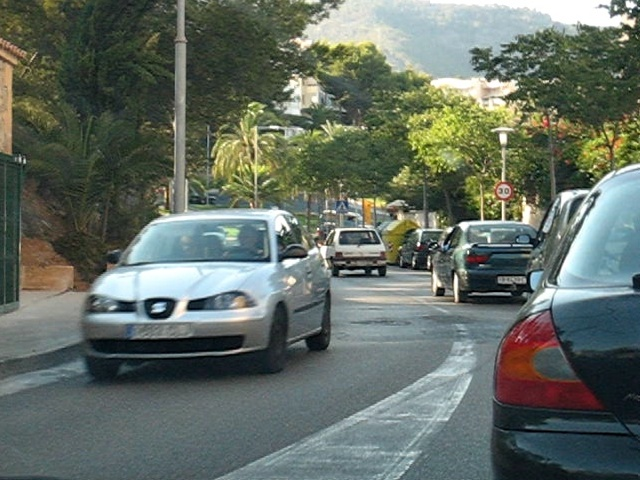

In [ ]:
dfd_val1 = dfd_rmse(im1, im2W)
print ('The DFD (SE) is {}'.format(dfd_val1))

APNG.from_files(["examples/car2W.jpg", "examples/car1.jpg"], delay=800).save("result.png")
Image('result.png')

<font color='red'><b>Q3: Explain the effects on the computation time and on the quality of the optical flow.</b></font>

<font color='blue'>Q3: Computation tinme decreases since it has to process less pyramid levels, so less total work. Also lower quality due to de aggressive downsamplig applied. It is less accurate and that leads to a higher DFD adn worse optical flow, specially on large displacements.</font>

## **2. Multi-Object tracking with DeepSORT**

In this part, you will learn how to perform object tracking with the [DeepSORT](https://arxiv.org/pdf/1703.07402.pdf) [5] algorithm.  The method is described by the key components of detection, propagating object states into future frames using a Kalman filter, associating current detections with existing objects, and managing the lifespan of tracked objects. The DeepSORT algorithm is an extension of [SORT](https://arxiv.org/pdf/1602.00763.pdf) [4], a very simple algorithm but with an excellent performance. DeepSORT improves the association step by adding an additional distance metric based on the appearance of the object. The appearance is modelled using a feature vector extracted from a CNN trained for classification. The association integrates motion and appearance information through combination of two appropriate metrics.

TASK:  Read the two papers and answer the following questions (related to the DeepSORT paper):

<font color='red'><b>Q4: Which metric is used to account for the motion information in the association problem?</b></font>

<font color='blue'>Mahalanobis distance</font>

<font color='red'><b>Q5: Which metric is used for the appearance information?</b></font>

<font color='blue'>Cosine distance</font>

<font color='red'><b>Q6: How are both metrics combined to provide the final association result?</b></font>

<font color='blue'>Combined via a weighted sum cost matrix: c(i,j) = λ * Mahalanobis(i,j) + (1-λ) * Cosine(i,j) </font>

Now, we will use DeepSORT for person tracking in a video sequence.


The original DeepSORT github repository code is built only for validating the algorithm with the MARS test dataset. We will be using a different [repository](https://github.com/abhyantrika/nanonets_object_tracking/), which includes a custom class deepsort.py that acts as a bridge and also takes in any custom configurations like a different feature extractor and other parameters.

In [ ]:
%cd /content/
#!git clone https://github.com/rmorros/deepsort-lab.git
%cd deepsort-lab

/Users/esteve/dev/cvdl/motion_tracking/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


[Errno 2] No such file or directory: '/content/'
/Users/esteve/dev/cvdl/motion_tracking/pyflow/pyflow
Cloning into 'deepsort-lab'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 62 (delta 19), reused 47 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 22.97 MiB | 2.78 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/Users/esteve/dev/cvdl/motion_tracking/content/pyflow/pyflow/deepsort-lab


/Users/esteve/dev/cvdl/motion_tracking/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


However, this code does not include an object detector (for simplicity, a video with pre-existing detection outputs is provided). To be able to use the code for any video, your task will be to modify the code to include an object detector.

You can use any detector available (classical or Deep Learning) which includes the class **person**. For instance, [YOLOv8](https://docs.ultralytics.com/tasks/detect/#predict), [Mobilenet SSD](https://https://www.pyimagesearch.com/2018/05/14/a-gentle-guide-to-deep-learning-object-detection/), [YOLO](https://www.pyimagesearch.com/2018/11/12/yolo-object-detection-with-opencv/) or any other you want.

In [4]:
import numpy as np
import cv2
import sys
from deepsort import *

from IPython.display import HTML
from base64 import b64encode
import os.path
import warnings

warnings.filterwarnings("ignore")


# Read Video sequence
if not os.path.isfile('videos/race.mp4'):
  print ('Can not find videos/race.mp4')
  exit

cap = cv2.VideoCapture('videos/race.mp4')

# Initialize writer
fourcc = cv2.VideoWriter_fourcc(*'MP4V')
out = cv2.VideoWriter('race_out.mp4',fourcc, 10.0, (1280,720))

#Initialize deep sort.
deepsort = deepsort_rbc()


ModuleNotFoundError: No module named 'deepsort'

<font color='red'><b>P2: Modify the following code to include an object detector. Draw a rectangle around each tracked object, using a different box color for each track.
Test the result on the provided video</b></font>

In [ ]:
#TODO: Initialize object detector

frame_id = 1

while True:
    print('Processing frame {}'.format(frame_id))
    ret,frame = cap.read()
    if ret is False:
        frame_id+=1
         break
    frame = frame.astype(np.uint8)

    # detections,out_scores = get_gt(frame,frame_id,gt_dict)
    # TODO: Get detections,out_scores from an object detector

    if len(detections) == 0:
        print("No dets")
        frame_id+=1
        continue

    detections = np.array(detections)
    out_scores = np.array(out_scores)

    tracker,detections_class = deepsort.run_deep_sort(frame,out_scores,detections)

    for track in tracker.tracks:
        if not track.is_confirmed() or track.time_since_update > 1:
            continue

        bbox = track.to_tlbr() #Get the corrected/predicted bounding box
        id_num = str(track.track_id) #Get the ID for the particular track.
        features = track.features #Get the feature vector corresponding to the detection.

        # Overlay bbox from tracker.
        cv2.rectangle(frame, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])),(255,255,255), 2)
        cv2.putText(frame, str(id_num),(int(bbox[0]), int(bbox[1])),0, 5e-3 * 200, (0,255,0),2)

    frame_id+=1
    out.write(frame)

# When everything done, release the capture
out.release()

Visualize the video with the overlayed detections to check that it works:

In [ ]:
# Transcode to h264, otherwise video is not visualizing in Colab
!ffmpeg -i race_out.mp4 -an -vcodec libx264 -crf 23 race_out2.mp4

# Extracted from https://stackoverflow.com/questions/57377185/how-play-mp4-video-in-google-colab
mp4 = open('race_out2.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=800 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

<font color='red'><b>Q7: Comment the obtained results: Which is the tracking rate (fps)? Are the labels of the objects maintained along the video sequence? In which situations does the method fail? Can you use the tracking to count the number of people in the race? Which is the frame-rate of the tracking?</b></font>

<font color='blue'>YOUR ANSWER HERE</font>

**REFERENCES**

[1] *T. Brox, A. Bruhn, N. Papenberg, and J.Weickert. High accuracy optical flow estimation based on a theory for warping. In European Conference on Computer Vision (ECCV), pages 25–36, 2004*

[2] *C. Liu. Beyond Pixels: Exploring New Representations and Applications for Motion Analysis. Doctoral Thesis. Massachusetts Institute of Technology. May 2009.*

[3] *C. Liu, "[Optical Flow Matlab/C++ Code](http://people.csail.mit.edu/celiu/OpticalFlow/)"*

[4] *Bewley, Alex et al. “Simple Online and Realtime Tracking.” 2016 IEEE International Conference on Image Processing (ICIP), 2016*

[5] *Nicolai Wojke and Alex Bewley and Dietrich Paulus, Simple Online and Realtime Tracking with a Deep Association Metric, arXiv 1703.07402, 2017*


**USEFUL RESOURCES**

*   [pyimagesearch Blog](https://www.pyimagesearch.com/blog)
*   [Nanonets.com Blog](https://nanonets.com/blog/object-tracking-deepsort/)



